In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline   

sns.set_style('whitegrid')
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [5]:
df = pd.read_csv('creditcard.csv')
print(f'Dataset loaded!')
print(f' Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

Dataset loaded!
 Rows: 284,807  |  Columns: 31


In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
#Checking null values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
#counting fraud vs normal
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

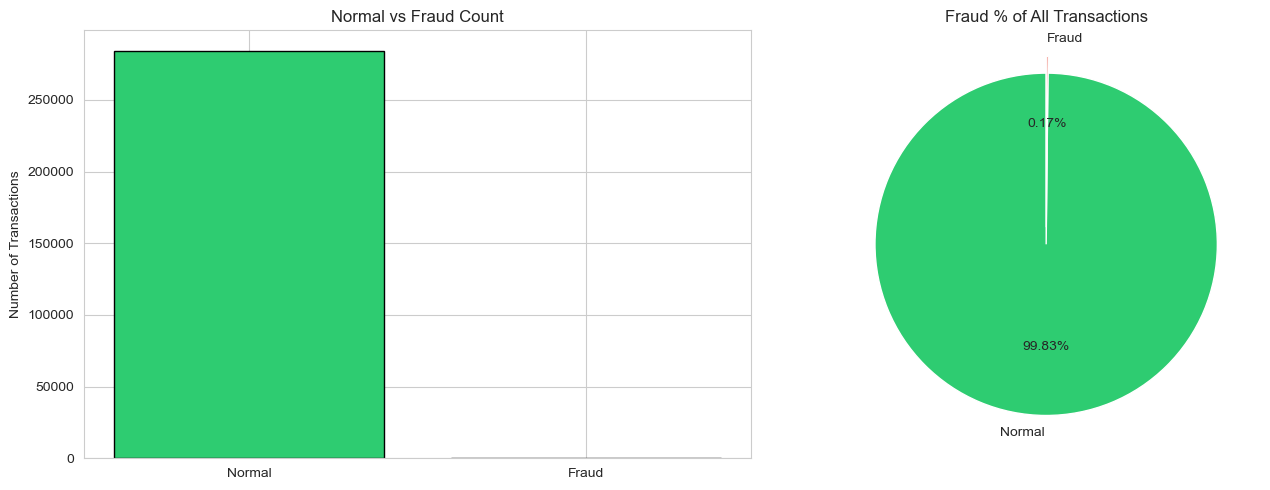

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Normal', 'Fraud'], fraud_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Normal vs Fraud Count')
axes[0].set_ylabel('Number of Transactions')

axes[1].pie(fraud_counts.values, labels=['Normal', 'Fraud'],
            autopct='%1.2f%%', colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Fraud % of All Transactions')

plt.tight_layout()
plt.savefig('chart1_fraud_vs_normal.png', dpi=150, bbox_inches='tight')
plt.show()

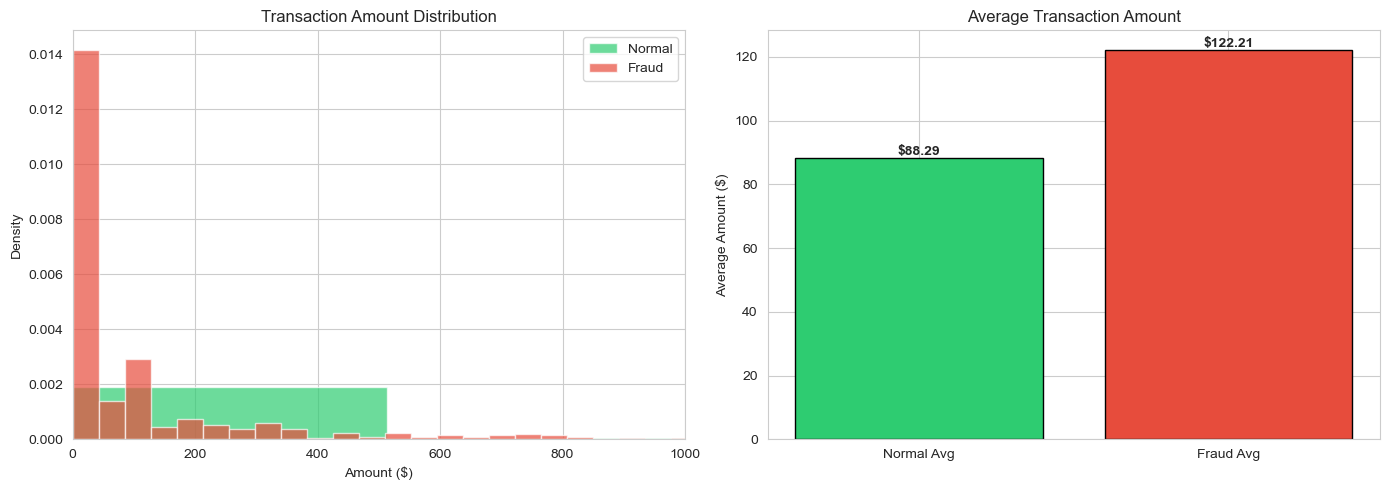

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal = df[df['Class'] == 0]['Amount']
fraud  = df[df['Class'] == 1]['Amount']

colors = ['#2ecc71', '#e74c3c']

# Left chart — distribution
axes[0].hist(normal, bins=50, color='#2ecc71', alpha=0.7, label='Normal', density=True)
axes[0].hist(fraud,  bins=50, color='#e74c3c', alpha=0.7, label='Fraud',  density=True)
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Right chart — averages
avg_amounts = [normal.mean(), fraud.mean()]
axes[1].bar(['Normal Avg', 'Fraud Avg'], avg_amounts, color=colors, edgecolor='black')
axes[1].set_title('Average Transaction Amount')
axes[1].set_ylabel('Average Amount ($)')

for i, v in enumerate(avg_amounts):
    axes[1].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_transaction_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

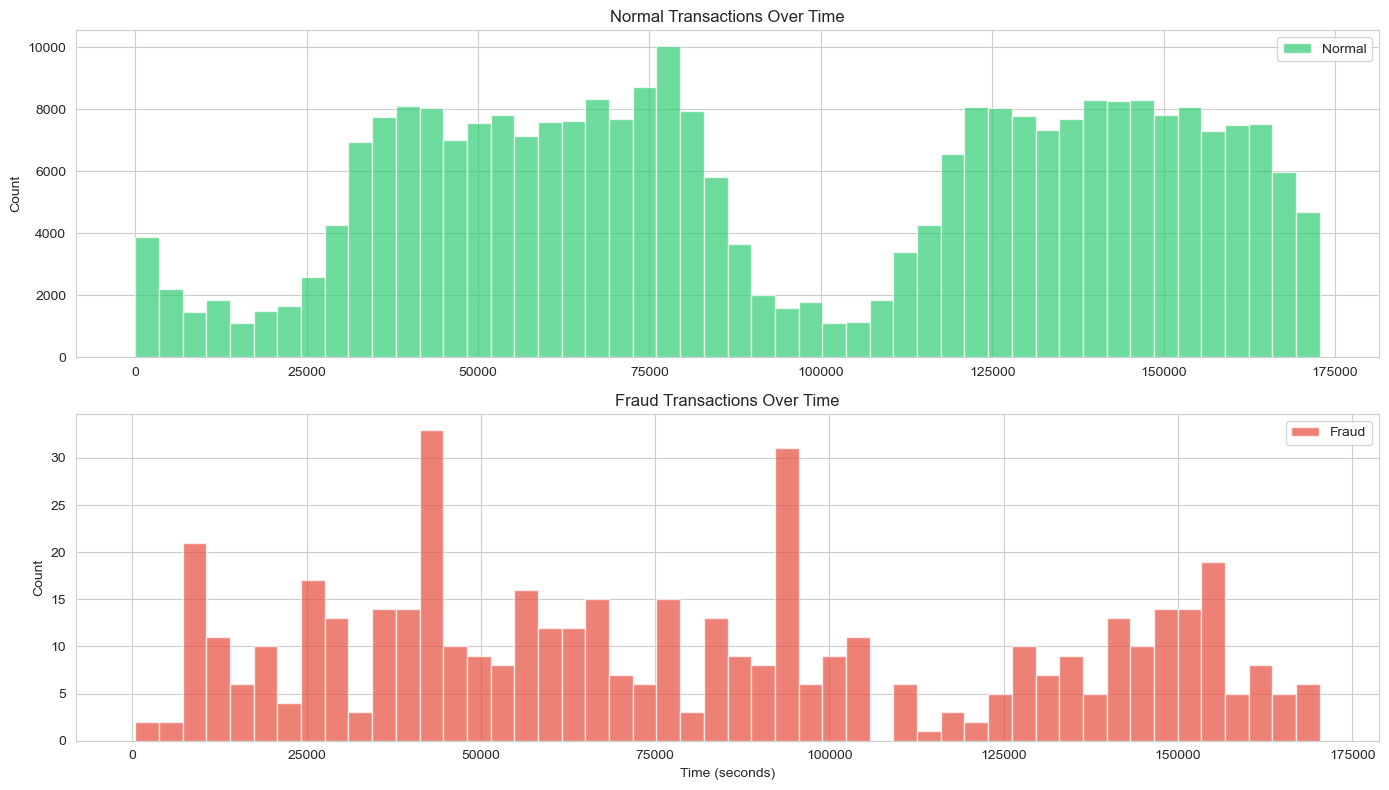

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].hist(df[df['Class']==0]['Time'], bins=50, color='#2ecc71', alpha=0.7, label='Normal')
axes[0].set_title('Normal Transactions Over Time')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df[df['Class']==1]['Time'], bins=50, color='#e74c3c', alpha=0.7, label='Fraud')
axes[1].set_title('Fraud Transactions Over Time')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart3_fraud_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
bins   = [0, 50, 100, 200, 500, 1000, 5000, 30000]
labels = ['$0-50', '$50-100', '$100-200', '$200-500', '$500-1K', '$1K-5K', '$5K+']

df['amount_bucket'] = pd.cut(df['Amount'], bins=bins, labels=labels)

bucket_analysis = df.groupby('amount_bucket', observed=True).agg(
    total=('Class', 'count'),
    fraud=('Class', 'sum')
).reset_index()

bucket_analysis['fraud_rate_%'] = (bucket_analysis['fraud'] / bucket_analysis['total'] * 100).round(2)

print(bucket_analysis.to_string(index=False))

amount_bucket  total  fraud  fraud_rate_%
        $0-50 189220    279          0.15
      $50-100  37254     56          0.15
     $100-200  27671     45          0.16
     $200-500  19695     50          0.25
      $500-1K   6202     26          0.42
       $1K-5K   2885      9          0.31
         $5K+     55      0          0.00


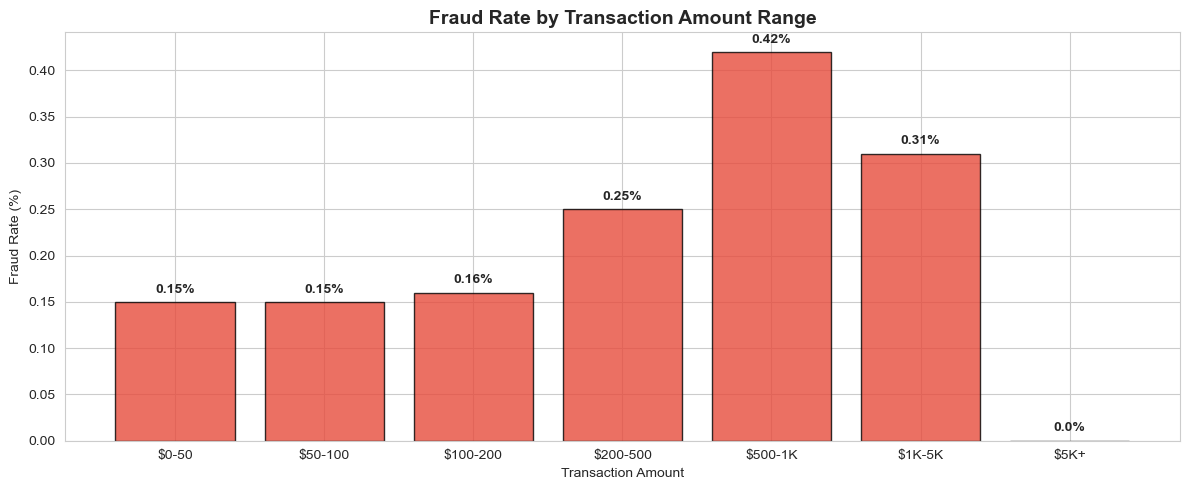

In [42]:
plt.figure(figsize=(12, 5))

bars = plt.bar(bucket_analysis['amount_bucket'].astype(str),
               bucket_analysis['fraud_rate_%'],
               color='#e74c3c', edgecolor='black', alpha=0.8)

plt.title('Fraud Rate by Transaction Amount Range', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Amount')
plt.ylabel('Fraud Rate (%)')

for bar, rate in zip(bars, bucket_analysis['fraud_rate_%']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_fraud_by_amount.png', dpi=150, bbox_inches='tight')
plt.show()


In [31]:
import sqlite3

conn = sqlite3.connect(':memory:')

df.to_sql('transactions', conn, index=False, if_exists='replace')

print('✅ Database ready! Table: transactions')

✅ Database ready! Table: transactions


In [32]:
query = """
SELECT *
FROM transactions
LIMIT 5
"""

result = pd.read_sql(query, conn)
result

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,amount_bucket
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,$100-200
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,$0-50
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,$200-500
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,$100-200
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,$50-100


In [33]:
query = """
SELECT 
    Class,
    COUNT(*)        AS total_transactions,
    ROUND(AVG(Amount), 2) AS avg_amount,
    ROUND(MAX(Amount), 2) AS max_amount,
    ROUND(MIN(Amount), 2) AS min_amount
FROM transactions
GROUP BY Class
"""

result = pd.read_sql(query, conn)
result

,Class,total_transactions,avg_amount,max_amount,min_amount
0,0,284315,88.29,25691.16,0.0
1,1,492,122.21,2125.87,0.0


In [34]:
query = """
SELECT 
    Time,
    Amount,
    Class,
    Amount - LAG(Amount) OVER (ORDER BY Time) AS amount_change,
    Time   - LAG(Time)   OVER (ORDER BY Time) AS seconds_since_last
FROM transactions
ORDER BY Time
LIMIT 20
"""

result = pd.read_sql(query, conn)
result


,Time,Amount,Class,amount_change,seconds_since_last
0,0.0,149.62,0,NaN,NaN
1,0.0,2.69,0,-146.93,0.0
2,1.0,378.66,0,375.97,1.0
3,1.0,123.50,0,-255.16,0.0
4,2.0,69.99,0,-53.51,1.0
5,2.0,3.67,0,-66.32,0.0
6,4.0,4.99,0,1.32,2.0
7,7.0,40.80,0,35.81,3.0
8,7.0,93.20,0,52.40,0.0
9,9.0,3.68,0,-89.52,2.0


In [35]:
query = """
SELECT
    Time,
    COUNT(*)                    AS transactions_same_second,
    SUM(Class)                  AS fraud_count,
    ROUND(SUM(Amount), 2)       AS total_amount,
    ROUND(AVG(Amount), 2)       AS avg_amount
FROM transactions
GROUP BY Time
HAVING COUNT(*) > 2
ORDER BY fraud_count DESC
LIMIT 15
"""

result = pd.read_sql(query, conn)
result

,Time,transactions_same_second,fraud_count,total_amount,avg_amount
0,68207.0,7,6,11.00,1.57
1,94362.0,4,4,4.00,1.00
2,93879.0,5,4,303.75,60.75
3,93860.0,5,4,596.85,119.37
4,93853.0,4,4,721.92,180.48
5,85285.0,5,4,515.34,103.07
6,84204.0,5,4,1139.50,227.90
7,148053.0,4,2,16.28,4.07
8,169347.0,4,1,13.40,3.35
9,167338.0,4,1,495.49,123.87


In [36]:
query = """
SELECT
    CAST(Time/3600 AS INT)                   AS hour_of_day,
    COUNT(*)                                 AS total_transactions,
    SUM(Class)                               AS fraud_count,
    ROUND(SUM(Class) * 100.0 / COUNT(*), 3) AS fraud_rate_pct
FROM transactions
GROUP BY hour_of_day
ORDER BY fraud_rate_pct DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
result

,hour_of_day,total_transactions,fraud_count,fraud_rate_pct
0,26,1752,36,2.055
1,28,1127,17,1.508
2,2,1576,21,1.332
3,3,1821,13,0.714
4,7,3368,23,0.683
5,5,1681,11,0.654
6,4,1082,6,0.555
7,11,8517,43,0.505
8,25,2003,8,0.399
9,23,6082,17,0.280


In [37]:
sql_queries = """
-- =============================================
-- Credit Card Fraud Detection — SQL Analysis
-- =============================================

-- Query 1: Basic Fraud Summary
SELECT 
    Class,
    COUNT(*)                    AS total_transactions,
    ROUND(AVG(Amount), 2)       AS avg_amount,
    ROUND(MAX(Amount), 2)       AS max_amount,
    ROUND(MIN(Amount), 2)       AS min_amount
FROM transactions
GROUP BY Class;


-- Query 2: High Frequency Suspicious Transactions
SELECT
    Time,
    COUNT(*)                            AS transactions_same_second,
    SUM(Class)                          AS fraud_count,
    ROUND(SUM(Amount), 2)               AS total_amount,
    ROUND(AVG(Amount), 2)               AS avg_amount
FROM transactions
GROUP BY Time
HAVING COUNT(*) > 2
ORDER BY fraud_count DESC
LIMIT 15;


-- Query 3: Hourly Fraud Patterns
SELECT
    CAST(Time/3600 AS INT)                   AS hour_of_day,
    COUNT(*)                                 AS total_transactions,
    SUM(Class)                               AS fraud_count,
    ROUND(SUM(Class) * 100.0 / COUNT(*), 3) AS fraud_rate_pct
FROM transactions
GROUP BY hour_of_day
ORDER BY fraud_rate_pct DESC
LIMIT 10;
"""

# Save to a .sql file
with open('fraud_queries.sql', 'w') as f:
    f.write(sql_queries)

print('✅ SQL queries saved as fraud_queries.sql!')

✅ SQL queries saved as fraud_queries.sql!
